# Email Appendix: EDA and Model Evidence

This appendix expands the email/message portion of the final prototype evidence notebook. The master reference remains `notebooks/00_final_prototype_evidence_notebook.ipynb`.

Purpose: document email dataset readiness, label balance, saved model metrics, artifact ownership, and dashboard traceability without rerunning slow training inside the notebook.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

def project_path(relative: str) -> Path:
    return ROOT / relative

def load_json(relative: str) -> dict:
    path = project_path(relative)
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else {}

def status(path: Path) -> str:
    return "PASS" if path.exists() else "CHECK"

ROOT

WindowsPath('C:/Users/user/Documents/Codex/ai-scam-detector')

## Dashboard Input, Visible Output, and Report Handoff

This appendix starts from what a reviewer or user can see in the dashboard, then connects that visible result to the saved evidence fields used by the report generator. This keeps the notebook practical: it explains not only model accuracy, but also how dashboard information becomes report-ready text.

In [2]:
dashboard_io_rows = [
    {
        "Dashboard step": "Provide email/message evidence",
        "User-visible input": "Paste text or upload EML, MSG, TXT, HTML, PDF, DOCX, or CSV evidence.",
        "User-visible output": "Evidence preview, uploaded file card, file metadata, and editable text area.",
        "Report/history fields": "preview, raw_input, source_name or uploaded filename where available",
        "Documentation note": "This proves what text the model inspected.",
    },
    {
        "Dashboard step": "Choose email models",
        "User-visible input": "Toggle one or more trained email model families.",
        "User-visible output": "Model comparison table, suspicious vote count, average risk, highest confidence, and engine labels.",
        "Report/history fields": "prediction, confidence, model/model_name",
        "Documentation note": "This connects model selection to the result shown to the reviewer.",
    },
    {
        "Dashboard step": "Review explanations",
        "User-visible input": "No extra input; explanations are generated from the analysed text and selected diagnostic model.",
        "User-visible output": "Rule indicators, legitimate-context indicators, model-influential terms, confidence chart, and decision trace.",
        "Report/history fields": "Core email history currently stores the result and raw text; some visual explanation tables should be cited as dashboard evidence if not persisted.",
        "Documentation note": "Separate visible explanation evidence from fields that are definitely stored.",
    },
    {
        "Dashboard step": "Convert to report evidence",
        "User-visible input": "Open AI Report Generator and select saved Email evidence rows.",
        "User-visible output": "Report preview and TXT/PDF/DOCX download.",
        "Report/history fields": "scan_type, prediction, confidence, model_name, preview, raw_input",
        "Documentation note": "This is the final handoff from dashboard result to shareable report.",
    },
]

pd.DataFrame(dashboard_io_rows)

,Dashboard step,User-visible input,User-visible output,Report/history fields,Documentation note
0,Provide email/message evidence,"Paste text or upload EML, MSG, TXT, HTML, PDF,...","Evidence preview, uploaded file card, file met...","preview, raw_input, source_name or uploaded fi...",This proves what text the model inspected.
1,Choose email models,Toggle one or more trained email model families.,"Model comparison table, suspicious vote count,...","prediction, confidence, model/model_name",This connects model selection to the result sh...
2,Review explanations,No extra input; explanations are generated fro...,"Rule indicators, legitimate-context indicators...",Core email history currently stores the result...,Separate visible explanation evidence from fie...
3,Convert to report evidence,Open AI Report Generator and select saved Emai...,Report preview and TXT/PDF/DOCX download.,"scan_type, prediction, confidence, model_name,...",This is the final handoff from dashboard resul...


## Dataset Readiness

Email/message models are trained from processed text examples. The final notebook treats this as a text-classification channel: raw email/message sources are prepared into a consistent CSV, then TF-IDF features and candidate classifiers are evaluated.

In [3]:
email_path = project_path("data/processed/email/email_dataset.csv")
email_df = pd.read_csv(email_path) if email_path.exists() else pd.DataFrame()

pd.DataFrame([
    {
        "Evidence item": "Processed email dataset",
        "Path": str(email_path.relative_to(ROOT)),
        "Status": status(email_path),
        "Rows": len(email_df),
        "Columns": len(email_df.columns),
        "Label column present": "label" in email_df.columns,
    }
])

,Evidence item,Path,Status,Rows,Columns,Label column present
0,Processed email dataset,data\processed\email\email_dataset.csv,PASS,33884,4,True


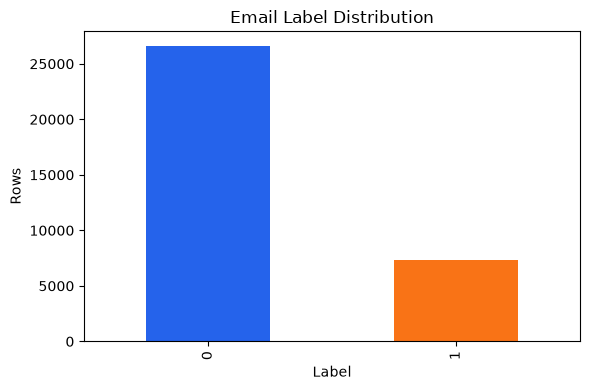

In [4]:
if not email_df.empty and "label" in email_df.columns:
    counts = email_df["label"].value_counts().sort_index()
    ax = counts.plot(kind="bar", figsize=(6, 4), color=["#2563EB", "#F97316"])
    ax.set_title("Email Label Distribution")
    ax.set_xlabel("Label")
    ax.set_ylabel("Rows")
    plt.tight_layout()
else:
    print("Processed email dataset or label column is ready for review.")

## Model Selection Evidence

The email workflow compares candidate TF-IDF classifiers such as Naive Bayes, Decision Tree, SVM, Random Forest, and XGBoost where available. The selected benchmark is based on saved validation metrics loaded during dashboard use.

In [5]:
email_metrics = load_json("reports/metrics/email_model_metrics.json")
selected_name = email_metrics.get("best_model") or email_metrics.get("top_validation_model")
rows = []
for model_name, metrics in email_metrics.get("models", {}).items():
    rows.append({
        "Model": model_name,
        "Selected benchmark": "Yes" if model_name == selected_name else "No",
        "Accuracy": metrics.get("accuracy"),
        "Precision": metrics.get("precision"),
        "Recall": metrics.get("recall"),
        "F1": metrics.get("f1"),
        "ROC-AUC": metrics.get("roc_auc"),
    })

metric_df = pd.DataFrame(rows)
metric_df.sort_values("F1", ascending=False) if not metric_df.empty else pd.DataFrame([{"Status": "No saved email metric rows found"}])

,Model,Selected benchmark,Accuracy,Precision,Recall,F1,ROC-AUC
2,SVM,Yes,0.997787,0.995196,0.994513,0.994854,0.999968
4,XGBoost,No,0.996754,0.992455,0.992455,0.992455,0.999903
3,Random Forest,No,0.993065,0.976367,0.991770,0.984008,0.999714
0,Naive Bayes,No,0.987605,0.997106,0.945130,0.970423,0.999609
1,Decision Tree,No,0.980670,0.934512,0.978738,0.956114,0.994446


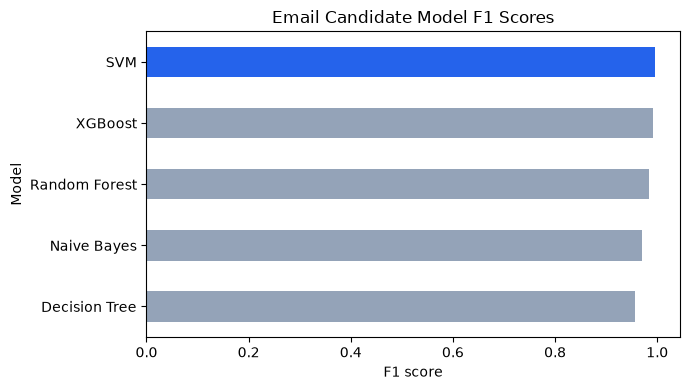

In [6]:
if not metric_df.empty and "F1" in metric_df.columns:
    plot_df = metric_df.sort_values("F1", ascending=True)
    colors = ["#2563EB" if value == "Yes" else "#94A3B8" for value in plot_df["Selected benchmark"]]
    ax = plot_df.plot.barh(x="Model", y="F1", figsize=(7, 4), color=colors, legend=False)
    ax.set_title("Email Candidate Model F1 Scores")
    ax.set_xlabel("F1 score")
    plt.tight_layout()
else:
    print("No email model metrics available for plotting.")

## Runtime Artifact And Source Traceability

The dashboard loads saved artifacts. This appendix records the files that connect training output to the Email/message tab.

In [7]:
artifact_paths = [
    "models/email_vectorizer.pkl",
    "models/email_nb.pkl",
    "models/email_dt.pkl",
    "models/email_svm.pkl",
    "models/email_rf.pkl",
    "models/email_xgb.pkl",
    "models/email_best.pkl",
    "reports/metrics/email_model_metrics.json",
    "app/email_tab.py",
    "src/training/email_trainer.py",
    "scripts/04_train_email_model.py",
]

pd.DataFrame([
    {"Path": relative, "Status": status(project_path(relative))}
    for relative in artifact_paths
])

,Path,Status
0,models/email_vectorizer.pkl,PASS
1,models/email_nb.pkl,PASS
2,models/email_dt.pkl,PASS
3,models/email_svm.pkl,PASS
4,models/email_rf.pkl,PASS
5,models/email_xgb.pkl,PASS
6,models/email_best.pkl,PASS
7,reports/metrics/email_model_metrics.json,PASS
8,app/email_tab.py,PASS
9,src/training/email_trainer.py,PASS


## Reviewer Note

Email metrics help explain why the selected benchmark is useful, but they should not be presented as universal real-world accuracy. The Email/message tab remains an educational decision-support tool that highlights evidence for human review.